In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import itertools
import os

In [11]:
# df = pd.read_csv('../reports/python3_report/pairs.csv')
# df.sort_values('similarity', ascending=False, inplace=True)

df = pd.DataFrame()
valid_questions = set(submission["problem_number"] for submission in json.load(open(
        "../data/parsed_submissions.json", "r", encoding="utf-8")))
languages = ["cpp", "c", "csharp", "golang", "java",
                 "javascript", "python", "python3", "rust"]
for question, lang in itertools.product(valid_questions, languages):
    if not os.path.exists(f'../reports/{question}/{lang}_report/pairs.csv'):
        continue
    report_df = pd.read_csv(f'../reports/{question}/{lang}_report/pairs.csv')
    report_df['language'] = lang
    report_df['question'] = question
    report_df['submission_id_left'] = report_df['leftFilePath'].map(lambda x: int(x.split('.')[0].split('/')[-1]))
    report_df['submission_id_right'] = report_df['rightFilePath'].map(lambda x: int(x.split('.')[0].split('/')[-1]))
    df = pd.concat([df, report_df], ignore_index=True)

meta = pd.read_json('../data/parsed_submissions.json')

# meta
df = df.merge(meta[['submission_id', 'user_slug', 'problem_number', 'rank']], left_on='submission_id_left', right_on='submission_id', how='left')
df = df.merge(meta[['submission_id', 'user_slug', 'problem_number', 'rank']], left_on='submission_id_right', right_on='submission_id', how='left', suffixes=('_left_merge', '_right_merge'))
df

,id,leftFileId,leftFilePath,rightFileId,rightFilePath,similarity,totalOverlap,longestFragment,leftCovered,rightCovered,...,submission_id_left,submission_id_right,submission_id_left_merge,user_slug_left_merge,problem_number_left_merge,rank_left_merge,submission_id_right_merge,user_slug_right_merge,problem_number_right_merge,rank_right_merge
0,3771,25,submissions/cpp/4410/2124445622.cpp,126,submissions/cpp/4410/2124456976.cpp,0.733945,80,38,40,40,...,2124445622,2124456976,2.124446e+09,undkwxWBze,4410.0,24.0,2.124457e+09,rudrapratapsingh11018,4410.0,71.0
1,4557,39,submissions/cpp/4410/2124447794.cpp,124,submissions/cpp/4410/2124514056.cpp,0.945205,69,26,34,35,...,2124447794,2124514056,2.124448e+09,Stefan_Salvatore_,4410.0,203.0,2.124514e+09,DhruviLadvaiya,4410.0,996.0
2,3005,6,submissions/cpp/4410/2124445284.cpp,18,submissions/cpp/4410/2124445887.cpp,0.817073,67,18,34,33,...,2124445284,2124445887,2.124445e+09,Kakumaniphaneendra2,4410.0,17.0,2.124446e+09,jatin_singh_07,4410.0,44.0
3,3692,25,submissions/cpp/4410/2124445622.cpp,18,submissions/cpp/4410/2124445887.cpp,0.631579,60,24,30,30,...,2124445622,2124445887,2.124446e+09,undkwxWBze,4410.0,24.0,2.124446e+09,jatin_singh_07,4410.0,44.0
4,1959,5,submissions/cpp/4410/2124444679.cpp,66,submissions/cpp/4410/2124449603.cpp,1.000000,56,28,28,28,...,2124444679,2124449603,NaN,NaN,NaN,NaN,2.124450e+09,SouSuke_AiZeN,4410.0,328.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52139,3228,43,submissions/python3/4380/2124521880.py,57,submissions/python3/4380/2124532123.py,0.000000,0,0,0,0,...,2124521880,2124532123,2.124522e+09,10rKl6MptD,4380.0,379.0,2.124532e+09,SUBARAMD,4380.0,614.0
52140,3265,44,submissions/python3/4380/2124522282.py,49,submissions/python3/4380/2124522398.py,0.000000,0,0,0,0,...,2124522282,2124522398,2.124522e+09,isa773,4380.0,384.0,2.124522e+09,ZuberShaikh,4380.0,484.0
52141,3296,49,submissions/python3/4380/2124522398.py,52,submissions/python3/4380/2124529939.py,0.000000,0,0,0,0,...,2124522398,2124529939,2.124522e+09,ZuberShaikh,4380.0,484.0,2.124530e+09,Praneeth_9574,4380.0,582.0
52142,3322,46,submissions/python3/4380/2124522536.py,60,submissions/python3/4380/2124546972.py,0.000000,0,0,0,0,...,2124522536,2124546972,2.124523e+09,unravel-iso-exp,4380.0,387.0,2.124547e+09,Manasi_Maharana,4380.0,717.0


In [12]:
df_cleaned = df[df['similarity'] > 0]

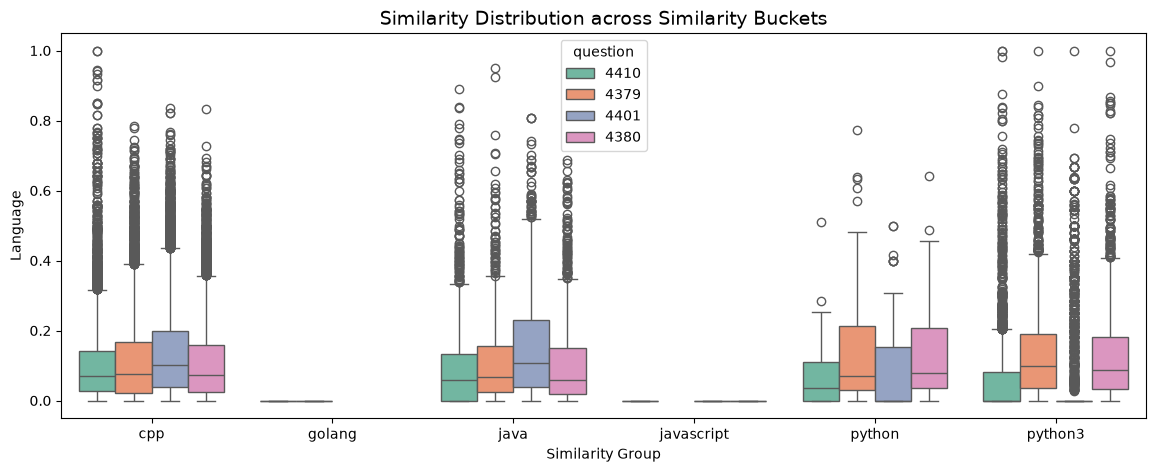

In [13]:
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='language', y='similarity', hue='question', palette='Set2')

plt.title('Similarity Distribution across Similarity Buckets', fontsize=14)
plt.xlabel('Similarity Group')
plt.ylabel('Language')
plt.show()
